# Tutorial 1: Quick Start

This tutorial explains how to use the higher-level API of the `nucmc` package to perform nucleosome positioning Monte Carlo simulations. The following steps are conducted within a Jupyter notebook environment. Jupyter notebook is not automatically provided within the supplied Conda environment, but it can be installed as follows:

```bash
conda activate nucmc
conda install jupyterlab ipywidgets
```

<div class="alert alert-info">
    
**Note:** It is not required to use Jupyter notebook to run the commands in this tutorial. Using the terminal and the default Python interpreter will work just fine, although bash commands will need to be run without '!' preceeding them.

</div>

## Prerequisite data files

To begin, we download some example methylation footprinting data for the promoter region of the gene *Oct4*, with a coverage of 5 kbp. These data are available from the GitLab repository, and they would have been automatically downloaded when doing `git clone` of the project and stored in `example/tut01_quick_start/experiment/raw_data` from the project root directory. There are four files in this directory:
* `segments.size` - a file containing the size of each DNA fiber segment.
* `chromatin.tsv` - the methylation footprinting scores outputted from ModKit for chromatinized DNA.
* `unmethylated.tsv` - footprinting scores for control samples where the DNA fibers are unmethylated.
* `methylated.tsv` - footprinting scores for control samples where the fibers are fully methylated.

`segments.size` simply contains the identifier and length (in bp) of the DNA segment:

In [1]:
!cat example/tut01_quick_start/experiment/raw_data/segments.size

chrom	length
Oct4	5000


And here we show the top few lines of the `chromatin.tsv` file generated from ModKit (note that these files have already been trimmed to include only the necessary columns in order to reduce file size):

In [2]:
!head -n5 example/tut01_quick_start/experiment/raw_data/chromatin.tsv

read_id	ref_position	chrom	ref_strand	mod_qual	mod_code
07d5beb4-3042-4944-b42e-013c35c65dd2	65	Oct4	+	0.42382813	a
07d5beb4-3042-4944-b42e-013c35c65dd2	66	Oct4	+	0.8691406	a
07d5beb4-3042-4944-b42e-013c35c65dd2	71	Oct4	+	0.39257813	a
07d5beb4-3042-4944-b42e-013c35c65dd2	74	Oct4	+	0.17773438	a


<div class="alert alert-info">

**Note:** It is important to keep the header when outputting the data from ModKit. `nucmc` uses this to identify the relevant data columns to keep for any downstream analysis. 

</div>

`nucmc` requires data from the following columns of the ModKit output tab-delimited file (as per modkit `extract full` output, see <https://nanoporetech.github.io/modkit/intro_extract.html>):

| Column name  | Description                                             | Loaded column index |
|--------------|---------------------------------------------------------|---------------------|
| read_id      | name of the read                                        | 0                   |
| ref_position | aligned 0-based reference sequence position             | 1                   |
| chrom        | name of aligned contig                                  | 2                   |
| ref_strand   | strand of the reference read is aligned to              | 3                   |
| mod_qual     | probability of the base modifcation in the next column  | 4                   |
| mod_code     | base modification code from the MM tag                  | 5                   |

## Loading the data files and performing normalization

The first step towards performing the simulations is loading the data above into an `MethPrintExperiment` object. We set up some variables for convenience:

In [3]:
from pathlib import Path

exp_dir = Path("example/tut01_quick_start/experiment")
raw_dir = exp_dir/"raw_data"
chromsize = raw_dir/"segments.size"
test_file = raw_dir/"chromatin.tsv"
unmeth_file = raw_dir/"unmethylated.tsv"
meth_file = raw_dir/"methylated.tsv"

The data files above can be loaded using the `nucmc.preprocess` method. Note that you need to write out the parameter names when passing the arguments - this also applies to most methods within the package:

In [4]:
import nucmc

exp_data = nucmc.preprocess(chromsize=chromsize, 
                            test_file=test_file,
                            unmeth_file=unmeth_file,
                            meth_file=meth_file,
                            norm_by_strand=True)

Reading example/tut01_quick_start/experiment/raw_data/chromatin.tsv ...
Reading example/tut01_quick_start/experiment/raw_data/unmethylated.tsv ...
Reading example/tut01_quick_start/experiment/raw_data/methylated.tsv ...


`exp_data` is a `MethPrintExperiment` object, which contains only the relevant attributes from the ModKit output that we need for running the simulations. We can use the `raw` property to access these underlying data (as `MethPrintData` objects). For instance, to view the methylation footprinting data for the chromatinized DNA fiber (i.e., the test condition) for *Oct4*, we use the `test_data` property, which returns a Pandas data frame of the underlying data:

In [5]:
exp_data.raw["Oct4"].test_data

,mol_index,pos,strand,mod_qual,mod_code
0,0,94,-,0.267578,a
1,0,96,-,0.095703,a
2,0,102,-,0.470703,a
3,0,104,-,0.052734,a
4,0,107,-,0.896484,m
...,...,...,...,...,...
122760,99,4961,-,0.744141,a
122761,99,4964,-,0.958984,a
122762,99,4966,-,0.134766,a
122763,99,4984,-,0.044922,m


Here, the program has automatically replaced the actual string-based `read_id` of the molecule with `mol_index` (an integer) to save storage space. The actual mapping between `mol_index` and `read_id` (for the test condition) can be accessed using the `test_mol_id` property, and we show here the first 10 of these read IDs:

In [6]:
exp_data.raw["Oct4"].test_mol_id[:10]

<StringArray>
['03cbfa4f-8cb0-443d-83ca-4b52dd61d8a8',
 '07d5beb4-3042-4944-b42e-013c35c65dd2',
 '0b9d1d65-18dd-4457-b857-83970b889456',
 '0ccc2d6f-189a-456a-a687-2b4bcdb11591',
 '0cd8ec6e-f3fd-44fd-8246-e2aa19950583',
 '16f2beee-c0f0-4b6f-91c7-241247909960',
 '1735c610-483f-4bfd-a9b1-97771835bf1b',
 '1d87be49-5dbe-4b52-81b6-706c5897f57a',
 '1d9f713f-9e23-4a8b-8c45-107f0f222ee0',
 '1f3b094d-80c3-45d4-b8f3-1515501faa8b']
Length: 10, dtype: str

We can access the unmethylated and methylated fiber raw data in a similar way using the properties `unmeth_data` and `meth_data`, respectively, and their molecule read IDs using `unmeth_mol_id` and `meth_mol_id`.

<div class="alert alert-info">

**Note:** Any operations on or modifications of the Pandas data frames containing the raw data are done on a copy, so the original data are unaffected. The data frame copies are not saved; hence, it is best to utilize the `analysis` property (see below) to add any modifications or annotations to the data. Note also that molecule read IDs are returned as non-writeable NumPy arrays.
    
</div>

Apart from loading the raw data, the `preprocess` method performs smoothing and normalization so that the data are ready for performing simulations. The smoothing step applies a fixed-size rolling window averaging of the methylation score signal for each molecule, and the default window size $\ell_{\text{bin}}$ is the typical footprint $\ell_{\text{nuc}} = 147$ bp of a nucleosome bound to DNA. The smoothed data are stored in `exp_data.analysis`, a dictionary of data frames containing any analysis results for each chromosome or DNA segment. Specifically, we access these smoothed data via the keys `test_smoothed`, `unmeth_smoothed`, and `meth_smoothed`:

In [7]:
exp_data.analysis["Oct4"]["test_smoothed"]

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
mol_index,,,,,,,,,,,,,,,,,,,,,
0,0.401786,0.401786,0.401786,0.380078,0.380078,0.380078,0.380078,0.380078,0.377197,0.392578,...,0.510433,0.510433,0.510433,0.510433,0.510433,0.510433,0.510433,0.510433,0.510433,0.510433
1,0.422960,0.422960,0.422960,0.422960,0.422960,0.433491,0.433491,0.433491,0.433491,0.433491,...,0.458999,0.458999,0.458999,0.458999,0.458999,0.458999,0.458999,0.458999,0.458999,0.458999
2,0.421725,0.421725,0.421725,0.421725,0.421725,0.443917,0.443917,0.443917,0.443917,0.443917,...,0.431663,0.431663,0.431663,0.431663,0.431663,0.431663,0.431663,0.431663,0.431663,0.431663
3,0.551693,0.551693,0.551693,0.561429,0.561429,0.561429,0.561429,0.561429,0.565918,0.558535,...,0.491139,0.491139,0.491139,0.491139,0.491139,0.491139,0.491139,0.491139,0.491139,0.491139
4,0.515104,0.515104,0.515104,0.523627,0.523627,0.523627,0.523627,0.523627,0.536865,0.527403,...,0.459803,0.459803,0.459803,0.459803,0.459803,0.459803,0.459803,0.459803,0.459803,0.459803
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.485286,0.485286,0.485286,0.489258,0.489258,0.489258,0.489258,0.489258,0.516889,0.510851,...,0.450538,0.450538,0.450538,0.450538,0.450538,0.450538,0.450538,0.450538,0.450538,0.450538
96,0.430525,0.430525,0.430525,0.441462,0.453585,0.453585,0.453585,0.466323,0.485973,0.488626,...,0.464085,0.464085,0.464085,0.464085,0.464085,0.464085,0.464085,0.464085,0.464085,0.464085
97,0.465541,0.465541,0.465541,0.454539,0.454539,0.454539,0.454539,0.454539,0.455599,0.461505,...,0.439241,0.439241,0.439241,0.439241,0.439241,0.439241,0.439241,0.439241,0.439241,0.439241


The normalization step in `preprocess` then tranforms these smoothed datasets into a methylation probability profile $p_M(x)$ for each molecule by scaling the data by their global minimum and maximum (see Simulation Model for more details). To avoid strong skewing arising from signal spikes, by default data are scaled with the extrema clipped such that any points rank below the 0.1% percentile (globally) are set to $p_M = 0$, and those rank above 99.9% are set to $p_M = 1$ (these thresholds can be altered via the `clip_low` and `clip_high` options).

Since we provide control datasets (fully methlyated and unmethylated DNA fibers), the normalization is done taking into account of them. Setting the option `norm_by_strand=True` ensures that normalization is done based on the strandedness of the molecule (i.e., data for `+` strand test molecules are normalized only against those for the `+` strand control molecules). The resulting $p_M$ is again stored in `exp_data.analysis`, and we look for its data via the key `meth_prob` in the data frame:

In [8]:
exp_data.analysis["Oct4"]["meth_prob"]

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
mol_index,,,,,,,,,,,,,,,,,,,,,
0,0.780063,0.780063,0.780063,0.799171,0.801012,0.801012,0.801012,0.803548,0.799836,0.789194,...,0.608282,0.608282,0.608282,0.608282,0.608282,0.608282,0.608282,0.608282,0.608282,0.608282
1,0.779043,0.783216,0.789117,0.789117,0.789117,0.786351,0.786351,0.786351,0.786351,0.764440,...,0.629272,0.629272,0.629272,0.629272,0.629272,0.629272,0.629272,0.629272,0.629272,0.629272
2,0.779829,0.783990,0.789871,0.789871,0.789871,0.780145,0.780145,0.780145,0.780145,0.757497,...,0.652278,0.652278,0.652278,0.652278,0.652278,0.652278,0.652278,0.652278,0.652278,0.652278
3,0.688662,0.688662,0.688662,0.692127,0.694729,0.694729,0.694729,0.698312,0.686904,0.689599,...,0.623597,0.623597,0.623597,0.623597,0.623597,0.623597,0.623597,0.623597,0.623597,0.623597
4,0.710971,0.710971,0.710971,0.714440,0.716884,0.716884,0.716884,0.720248,0.704290,0.708282,...,0.648470,0.648470,0.648470,0.648470,0.648470,0.648470,0.648470,0.648470,0.648470,0.648470
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.729151,0.729151,0.729151,0.734726,0.737026,0.737026,0.737026,0.740192,0.716244,0.718215,...,0.655823,0.655823,0.655823,0.655823,0.655823,0.655823,0.655823,0.655823,0.655823,0.655823
96,0.762541,0.762541,0.762541,0.762938,0.757933,0.757933,0.757933,0.753501,0.734744,0.731553,...,0.645071,0.645071,0.645071,0.645071,0.645071,0.645071,0.645071,0.645071,0.645071,0.645071
97,0.741190,0.741190,0.741190,0.755219,0.757373,0.757373,0.757373,0.760339,0.752920,0.747829,...,0.664791,0.664791,0.664791,0.664791,0.664791,0.664791,0.664791,0.664791,0.664791,0.664791


Here we show how to transform the data from left-aligned to center-aligned:

In [9]:
from nucmc.mapping import CoordsTransform
binsize = 147
coords = CoordsTransform(binsize=binsize)
centered = coords.left_to_center_aligned(exp_data.analysis["Oct4"]["meth_prob"])
exp_data.analysis["Oct4"]["meth_prob_centered"] = centered
centered

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
mol_index,,,,,,,,,,,,,,,,,,,,,
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.608282,0.608282,0.608282,0.608282,0.608282,0.608282,0.608282,0.608282,0.608282,0.608282
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.629272,0.629272,0.629272,0.629272,0.629272,0.629272,0.629272,0.629272,0.629272,0.629272
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.652278,0.652278,0.652278,0.652278,0.652278,0.652278,0.652278,0.652278,0.652278,0.652278
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.623597,0.623597,0.623597,0.623597,0.623597,0.623597,0.623597,0.623597,0.623597,0.623597
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.648470,0.648470,0.648470,0.648470,0.648470,0.648470,0.648470,0.648470,0.648470,0.648470
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.655823,0.655823,0.655823,0.655823,0.655823,0.655823,0.655823,0.655823,0.655823,0.655823
96,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.645071,0.645071,0.645071,0.645071,0.645071,0.645071,0.645071,0.645071,0.645071,0.645071
97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.664791,0.664791,0.664791,0.664791,0.664791,0.664791,0.664791,0.664791,0.664791,0.664791


This is now a good checkpoint to save the processed experimental data, which can be done using the `save` method. This stores the relevant raw data and analyses we have done into a single HDF5 file.

In [10]:
exp_h5 = exp_dir/"analysis.h5"
exp_data.save(exp_h5)

We can reload this file later using the `load` method:

In [11]:
from nucmc.experiment.methdata import MethPrintExperiment
new_exp_h5 = MethPrintExperiment.load(exp_h5)
print(new_exp_h5)

MethPrintExperiment(chroms, raw, analysis, global_analysis)


## Performing nucleosome positioning sampling simulations
To start the simulations, we first create a configuration file specifying the parameter values. At the moment, the package only supports annealing simulations, where the temperature of the system is gradually lowered during the simulation. The list of parameters required are as follows:

| Name          | Description
| ------------- | -----------------------------------------------------------------------------
| nucbp         | The amount of DNA (in bp) occupied by a bound nucleosome (e.g., 147 bp)
| llink         | Length (in bp) of the linker DNA
| mu            | Chemical potential (in units of $k_BT$; see Simulation Model). The energy associated with non-specific binding of nucleosome to DNA
| start_temp    | Start temperature
| end_temp      | End temperature
| cool_option   | How to adjust temperature over time. Options are "linear", "geometric", or "constant"
| nsweep        | Number of "sweeps" or timesteps in the simulation
| print_freq    | Frequency (in sweeps) at which to record simulation data
| emax          | The maximum energy cost allowed (in $k_BT$) from the methylation footprinting data

The file can be in `.json` or `.yml` format. For example, in `.yml` format the file looks as follows:

In [12]:
!cat example/tut01_quick_start/simulation/sim_params.yml

nucbp:       147
llink:       50
mu:          1.0
start_temp:  1.0
end_temp:    0.01
cool_option: "geometric"
nsweep:      1000000
print_freq:  1000
emax:        10.0

Alternatively, we can specify these parameters directly within python by utilizing the `SimSettings` object:

In [17]:
from nucmc.simulation.engine import SimSettings

settings = SimSettings(
    nucbp=147,
    llink=50,
    mu=1.0,
    start_temp=1.0,
    end_temp=0.01,
    cool_option="geometric",
    nsweep=20000,
    print_freq=100,
    emax=10)

Sometimes it may not be simple to determine an appropriate value for the chemical potential $\mu$ *a priori*. One could start with setting $\mu$ so that the energy landscape is effectively shifted with its median zeroed (or the "zero-point" energy), i.e., $\mu_z = \text{median}(E_{\text{seq}})$, as this should be the typical energy scale when nucleosomes will start binding. This can be done be setting $\mu$ to an arbitrary number (say 0) in the parameter list, and the use the option `use_zero_point_mu` in `nucmc.run` to modify $\mu = \mu_z$.

Next, we need to extract the methylation probabilities $p_M$ from the processed data and store them in a dictionary:

In [18]:
meth_prob = {"Oct4": exp_data.analysis["Oct4"]["meth_prob"]}

We now use the `nucmc.run` method to run the simulations. This method requires specifying the chromosomes (DNA segments) we would like to perform the sampling, the number of simulations to conduct per molecule (`nsim`), the simulation parameters (`settings`), and the methylation probability profile for each molecule in each chromosome (`meth_prob`). We also need to specify the output directory (`out_dir`) where the simulation results will be stored. The simulations can be run in parallel using multiple processes, and this is set via `nworker` (default is 1). By default, the `verbose` option is set to `True`, allowing a progress bar to be displayed in the terminal that provides an estimation of the time remaining before all jobs are complete.

In [20]:
sim_dir = Path("example/tut01_quick_start/simulation/result/") # Note that this dir must not exist
sim_data = nucmc.run(chroms=exp_data.chroms,
                     nsim=10,
                     seed=2346,
                     meth_prob=meth_prob,
                     settings=settings,
                     out_dir=sim_dir, 
                     nworker=20)

Output()

With `nworker=10`, the simulations should take around a few minutes to complete. Each simulation generates an HDF5 file containing the output data as specified by the `out_types` option in `run`. The default value for this option is `all`, including all information about the system such as its energy and temperature over time as well as the nucleosome positions. All simulation HDF5 files are located within the sub-directory `raw_data` in `out_dir`. Additionally, an overall dataset HDF5 file containing the metadata of the simulations and the downstream analysis is created and stored in `out_dir/results.h5` by default. The name of this file can be changed via the `dataset_name` option in `run`.

<div class="alert alert-info">
    
**Note:** Sub-directories within `raw_data` should not be touched, as `nucmc` relies on the file structure there to access the raw simulation data.

</div>

## Analyzing the simulation results

It is good practice to first inspect the raw simulation data and check that the results are reasonable before conducting any downstream analysis. To access the raw data from a specific simulation run (say run 0 for molecule 0 in *Oct4*), we use the `raw` property, which returns a `SimData` object:

In [21]:
sim_data.raw["Oct4",0,0]

SimData(nucbp, nbp, llink, mu, seed, time, energy, position, temp)

In [22]:
from pathlib import Path
from nucmc.simulation.results import SimDataset
sim_dir = Path("example/tut01_quick_start/simulation/result/")
sim_data = SimDataset.load(sim_dir/"results.h5")
sim_data.settings

DataclassPublicProxy(SimSettings(nucbp=np.int64(147), llink=np.int64(50), mu=np.float64(1.0), start_temp=np.float64(1.0), end_temp=np.float64(0.01), cool_option='geometric', nsweep=np.int64(10000), print_freq=np.int64(100), emax=np.int64(10)))

<div class="alert alert-info">
    
**Note:** All molecules and simulation runs are labelled using zero-based indexing.

</div>

Here, we can for instance inspect the total energy of the system over time, using the property `energy`:

In [23]:
sim_data.raw["Oct4",0,0].energy

array([ 0.        , -2.73845435, -2.17959596, -1.45790704, -2.86863286,
       -1.42772633, -3.0349709 , -1.84353031, -0.61031815, -3.95692419,
       -3.44079702, -3.57442209, -2.35565329, -1.2601394 , -3.32111432,
       -3.37797878, -1.56918081, -0.9364412 , -2.30745513, -2.46110411,
       -2.01102868, -2.4808871 , -3.07179163, -4.44969119, -3.71369336,
       -2.51878973, -3.78297562, -2.73615019, -3.49513142, -4.0933008 ,
       -3.72294679, -3.40356905, -3.65133488, -3.54216277, -4.24543757,
       -4.15190316, -3.61333107, -3.29850408, -4.82274224, -5.0679466 ,
       -4.53114746, -4.93960287, -4.24936631, -4.54644763, -4.98138385,
       -5.41446171, -4.97174527, -5.63218579, -5.52146154, -4.97605022,
       -4.78811087, -5.70792442, -5.60601155, -5.29767727, -5.51642697,
       -5.14732509, -6.02600842, -5.96661141, -5.8089735 , -5.81177031,
       -6.09000712, -5.4075985 , -5.80816375, -6.32185281, -6.32219455,
       -5.25614107, -5.70283049, -5.75739464, -6.29832775, -6.71

<div class="alert alert-info">
    
**Note:** Accessing simulation properties such as `energy` and `temp` (for the system's temperature) always returns a view of the underlying NumPy array that is non-writeable to preserve data integrity. The same applies to the property `position`, which returns a `Tuple` of non-writeable NumPy arrays of the nucleosome positions over time.

</div>

A good sanity check that we have run the simulation for long enough and that the system has reached a steady state is to see whether the total energy has stablized. We can plot the above time series of the energy values as follows:

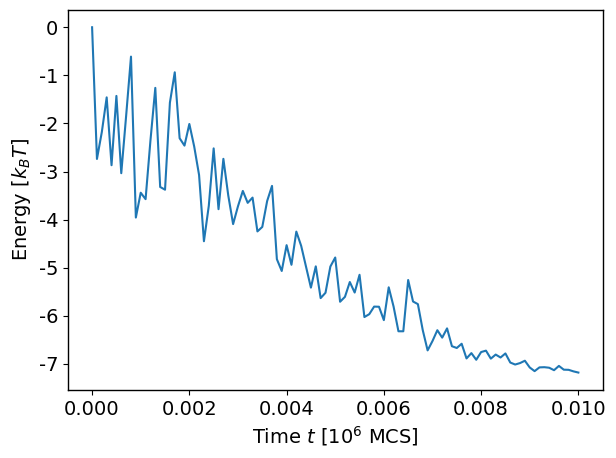

In [24]:
nucmc.plot_energy(chrom="Oct4", mol=0, run=0, dataset=sim_data)

We can see that the energy has gradually lowered and stablized at around $-6 k_BT$, and that fluctuations have minimized over time (reported in units of MCS, or number of Monte Carlo sweeps).

Another way to see whether the system has stablized is to plot the nucleosome positions over time as a heatmap. This can be done using the `nucmc.plot_nuc_pos` method, and it is useful to enable the `plot_eseq` option to show within the same plot the sequence-specific energy landscape $E_{\text{seq}}$ for the molecule derived from its methylation footprinting data.

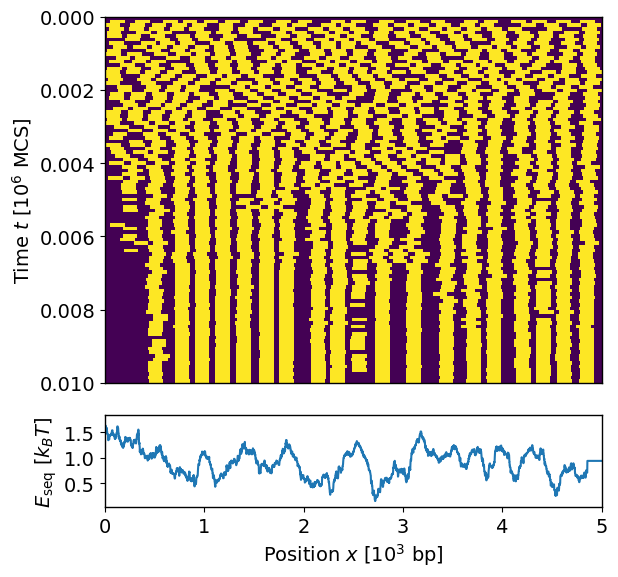

In [25]:
nucmc.plot_nuc_pos(chrom="Oct4", mol=0, run=0, dataset=sim_data, plot_eseq=True)

The nucleosome locations are shown in yellow in this plot, and they behave as one would expect: as the temperature decreases, the extent of repositioning and shuffling reduces, and the nucleosomes freeze into a final set of positions. Also, comparing with the energy landscape $E_{\text{seq}}$, we see that the nucleosomes tend to avoid the maxima and sit near the minima as expected. 

To get a sense of the overall picture of nucleosome positioning across all molecules, we use `nucmc.analyze` to perform some basic quantification of the simulated nucleosome positions:

In [26]:
nucmc.analyze(dataset=sim_data)

This method computes the average number of nucleosomes (`mean_nnuc`) and the average nucleosome occupancy (`occup`) for each molecule. The latter is defined as
$$
O_i(x) = \frac{1}{N_{\text{sim}}}\sum_{n=1}^{N_{\text{sim}}}s_i^{(n)}(x) \;,
$$
where $s_i^{(n)} = 1$ if, in the $n$th simulation, a nucleosome occcupies base-pair $x$ and $0$ otherwise.

These results are stored in `data.analysis`. For instance, to retrieve the average number of nucleosomes in each molecule in *Oct4*, we do the following:

In [27]:
sim_data.analysis["Oct4"]["mean_nnuc"]

,0
0,18.1
1,17.3
2,17.0
3,15.9
4,16.5
...,...
95,15.4
96,17.9
97,13.6
98,17.5


To visualize the averaged nucleosome occupancy across all molecules, we use the `nucmc.plot_occup` method, and again we enable the `plot_eseq` option to see correspondence between the nucleosome positions and the underlying energy landscape: 

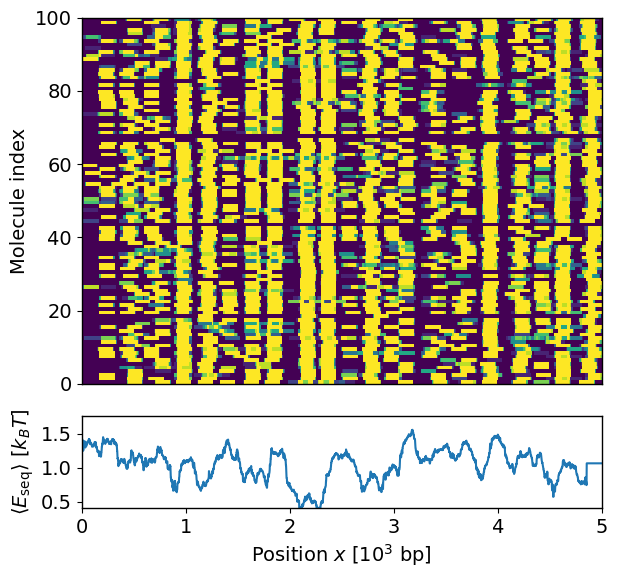

In [28]:
nucmc.plot_occup(chrom="Oct4", dataset=sim_data, plot_eseq=True)

Finally, we can save our analyses of the simulation results (in the HDF5 file `out_dir/results.h5`) that can be retrieved later for further post-processing:

In [22]:
sim_data.save()